# Seeing Superposition

Replication of the $W^T W$ heatmap experiment from [Elhage et al., 2022](https://transformer-circuits.pub/2022/toy_model/index.html).

Writeup: [Seeing Superposition](https://yeginbay.com/seeing-superposition)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
n_features = 20
hidden_dim = 5
batch_size = 1024
lr = 1e-3
steps = 10000
sparsities = [0.0, 0.7, 0.9, 0.97, 0.99]
n_models = len(sparsities)

In [4]:
class ToyModel(nn.Module):
    def __init__(self, n_features, hidden_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, n_features) / np.sqrt(n_features))
        self.b = nn.Parameter(torch.zeros(n_features))
    
    def forward(self, x):
        h = x @ self.W.T
        x_hat = h @ self.W + self.b
        return torch.relu(x_hat)

In [5]:
def generate_batch(batch_size, n_features, sparsity):
    x = torch.rand(batch_size, n_features)
    mask = torch.rand(batch_size, n_features) > sparsity
    return x * mask

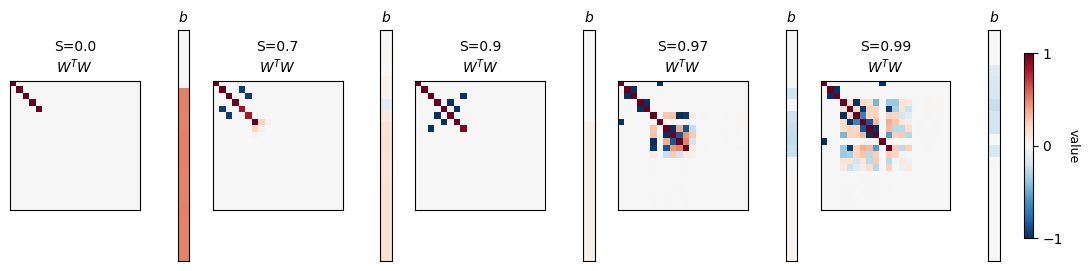

In [6]:
def train_model(sparsity, n_features=20, hidden_dim=5, batch_size=1024, steps=10000, lr=1e-3):
    I = 0.7 ** torch.arange(n_features, dtype=torch.float)
    
    model = ToyModel(n_features, hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for _ in range(steps):
        optimizer.zero_grad()
        x = generate_batch(batch_size, n_features, sparsity)
        x_hat = model(x)
        loss = (I * (x - x_hat)**2).mean()
        loss.backward()
        optimizer.step()
    
    return model
    
fig, axes = plt.subplots(
    1, 2 * n_models,
    figsize=(3 * n_models, 3),
    gridspec_kw={'width_ratios': [5, 1] * n_models}
)

im = None

for idx, s in enumerate(sparsities):
    model = train_model(s, n_features, hidden_dim, batch_size, steps, lr)
    W = model.W.detach().numpy()
    WtW = W.T @ W
    b = model.b.detach().numpy()
    
    ax_wtw = axes[2 * idx]
    ax_b   = axes[2 * idx + 1]
    
    im = ax_wtw.imshow(WtW, cmap='RdBu_r', vmin=-1, vmax=1)
    ax_wtw.set_title(f'S={s}\n$W^T W$', fontsize=10)
    ax_wtw.set_xticks([]); ax_wtw.set_yticks([])
    
    ax_b.imshow(b[:, None], cmap='RdBu_r', vmin=-1, vmax=1)
    ax_b.set_title('$b$', fontsize=10)
    ax_b.set_xticks([]); ax_b.set_yticks([])

fig.subplots_adjust(right=0.92, wspace=0.3)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, ticks=[-1, 0, 1])
cbar.ax.set_ylabel('value', rotation=270, labelpad=12, fontsize=9)

plt.show()